In [2]:
# libraries 

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

import sys; sys.path.append("..") #to direct program to the root files
from utils.get_data import get_processed_files


In [3]:
gfc_data = get_processed_files("..\\datasets\\processed\\gfc_data")
erc_20_dfs = get_processed_files("..\\datasets\\processed\\erc_20")


# 📉 2008 Global Financial Crisis (GFC)

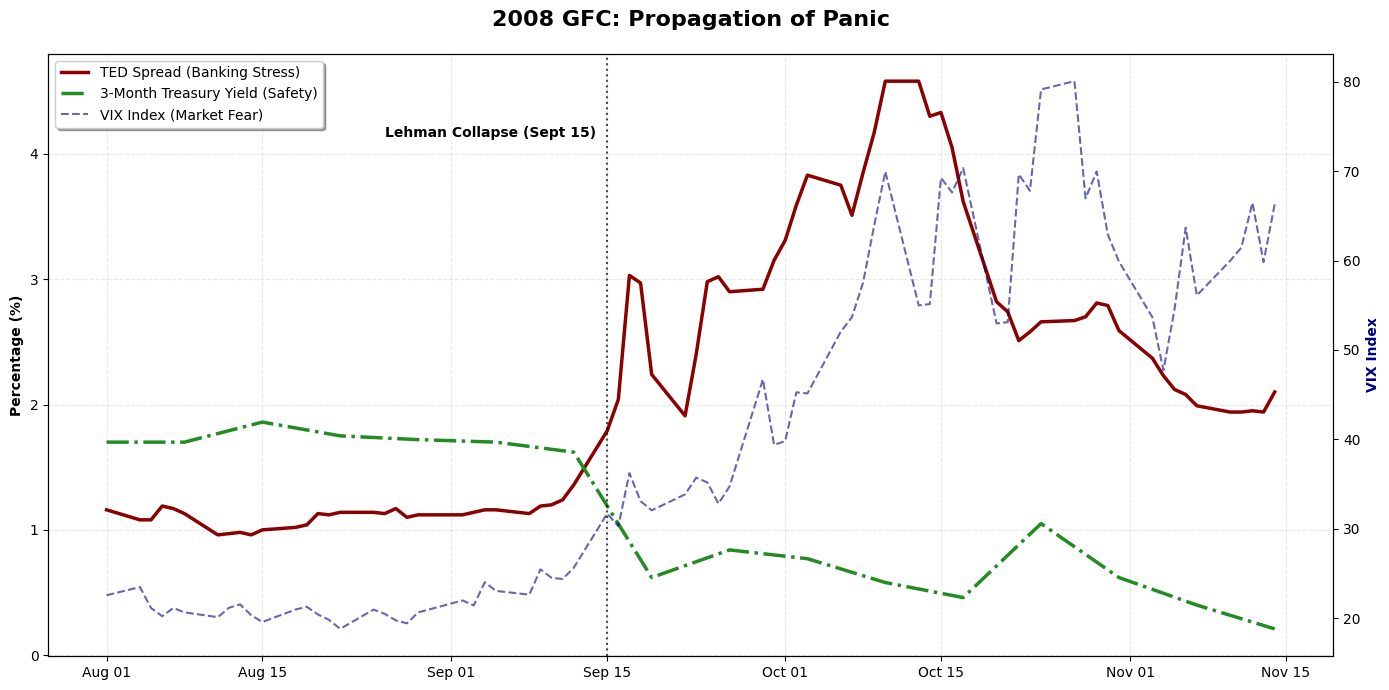

In [4]:

# 1. Load the processed datasets
ted_df = gfc_data['TEDRATE']
vix_df = gfc_data['^VIX']
wgs_df = gfc_data['WGS3MO']

# 2. Standardize dates
ted_df['date'] = pd.to_datetime(ted_df['date_standardized'])
vix_df['date'] = pd.to_datetime(vix_df['date_standardized'])
wgs_df['date'] = pd.to_datetime(wgs_df['date_standardized'])

# 3. Drop NaNs to fix "disconnected" gaps
ted_clean = ted_df.dropna(subset=['TEDRATE'])
vix_clean = vix_df.dropna(subset=['Close'])
wgs_clean = wgs_df.dropna(subset=['WGS3MO'])

# 4. Filter for the peak panic window
start, end = '2008-08-01', '2008-11-15'
ted_p = ted_clean[ted_clean['date'].between(start, end)]
vix_p = vix_clean[vix_clean['date'].between(start, end)]
wgs_p = wgs_clean[wgs_clean['date'].between(start, end)]

# 5. Create Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary Axis (Left): Percentages (%) for TED and Treasury Yields
lns1 = ax1.plot(ted_p['date'], ted_p['TEDRATE'], color='darkred', label='TED Spread (Banking Stress)', linewidth=2.5)
lns3 = ax1.plot(wgs_p['date'], wgs_p['WGS3MO'], color='forestgreen', label='3-Month Treasury Yield (Safety)', linewidth=2.5, linestyle='-.')
ax1.set_ylabel('Percentage (%)', color='black', fontweight='bold')

# Secondary Axis (Right): VIX Index
ax2 = ax1.twinx()
lns2 = ax2.plot(vix_p['date'], vix_p['Close'], color='navy', linestyle='--', label='VIX Index (Market Fear)', alpha=0.6)
ax2.set_ylabel('VIX Index', color='navy', fontweight='bold')

# 6. Lehman Annotation (Left Aligned)
lehman_date = pd.to_datetime('2008-09-15')
plt.axvline(x=lehman_date, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
plt.text(lehman_date - pd.Timedelta(days=1), 75, 'Lehman Collapse (Sept 15)', 
         va='top', ha='right', fontweight='bold', fontsize=10)

# 7. Legend & Formatting
lns = lns1 + lns3 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True, shadow=True)

plt.title("2008 GFC: Propagation of Panic", fontsize=16, fontweight='bold', pad=20)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()

os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/gfc_panic_propagation.png', dpi=300)
plt.show()

Chart focusing strictly on 2008 saved as: gfc_2008_propagation.png


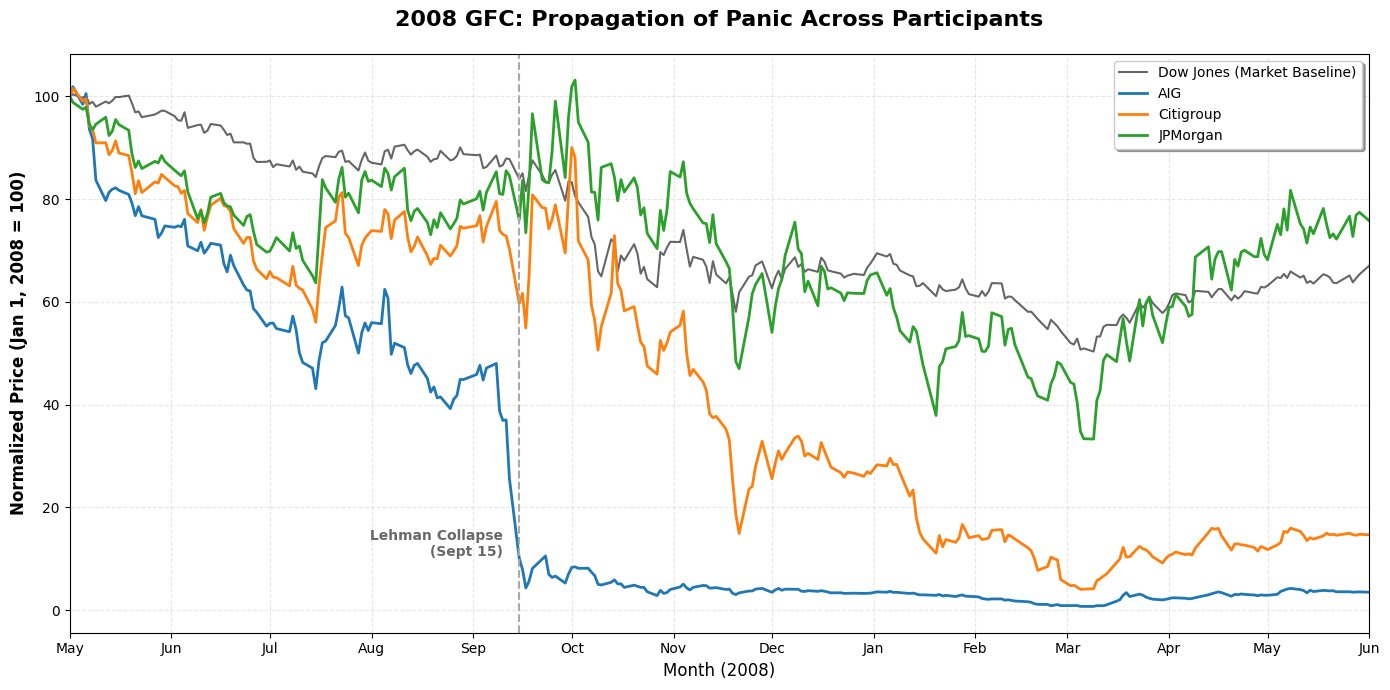

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the participant and indicator data
files = {
    'DJI': gfc_data['^DJI'],
    # 'GSPC': '../datasets/processed/gfc_data/processed_^GSPC.csv',
    # 'VIX': '../datasets/processed/gfc_data/processed_^VIX.csv',
    'AIG': gfc_data['AIG'],
    'Citi': gfc_data['C'],
    'JPM': gfc_data['JPM'],
    # 'TED': '../datasets/processed/gfc_data/processed_TEDRATE.csv',
    # 'WGS3MO': '../datasets/processed/gfc_data/processed_WGS3MO.csv'
}

data = {}
for name, path in files.items():
    df = path.copy()  # Use the already loaded DataFrame from gfc_data
    # Using the date column created in your pipeline
    df['date'] = pd.to_datetime(df['date_standardized'])
    data[name] = df.dropna(subset=['date'])

# Focus strictly on the year 2008
focus_start = '2008-05-01'
focus_end = '2009-06-01'

# Normalize function with strict start and end clipping
def normalize_and_clip(df, start, end):
    subset = df[(df['date'] >= start) & (df['date'] <= end)].sort_values('date').copy()
    if not subset.empty:
        # Normalize to 100 at the very start of the focus period (Jan 2008)
        initial_val = subset.iloc[0]['Close']
        subset['norm'] = (subset['Close'] / initial_val) * 100
    return subset

# Apply normalization and clipping
aig_2008 = normalize_and_clip(data['AIG'], focus_start, focus_end)
citi_2008 = normalize_and_clip(data['Citi'], focus_start, focus_end)
jpm_2008 = normalize_and_clip(data['JPM'], focus_start, focus_end)
dji_2008 = normalize_and_clip(data['DJI'], focus_start, focus_end)
# ted_2008 = data['TED'][(data['TED']['date'] >= focus_start) & (data['TED']['date'] <= focus_end)]

# Create the plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Plot Participant Performance (Left Axis)
ax1.plot(dji_2008['date'], dji_2008['norm'], color='black', linewidth=1.5, label='Dow Jones (Market Baseline)', alpha=0.6)
ax1.plot(aig_2008['date'], aig_2008['norm'], label='AIG', linewidth=2)
ax1.plot(citi_2008['date'], citi_2008['norm'], label='Citigroup', linewidth=2)
ax1.plot(jpm_2008['date'], jpm_2008['norm'], label='JPMorgan', linewidth=2)

ax1.set_ylabel('Normalized Price (Jan 1, 2008 = 100)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month (2008)', fontsize=12)

# 2. Plot TED Spread (Right Axis) - The Panic Indicator
# ax2 = ax1.twinx()
# ax2.fill_between(ted_2008['date'], ted_2008['TEDRATE'], color='red', alpha=0.1, label='TED Spread (Interbank Panic)')
# ax2.plot(ted_2008['date'], ted_2008['TEDRATE'], color='red', linestyle=':', linewidth=1.5, alpha=0.6)
# ax2.set_ylabel('TED Spread (%)', color='red', fontsize=12, fontweight='bold')
# ax2.tick_params(axis='y', labelcolor='red')

# 3. Lehman Annotation (Moved Left of Sept 15)
lehman_date = pd.to_datetime('2008-09-15')
ax1.axvline(x=lehman_date, color='darkgray', linestyle='--', linewidth=1.5)
ax1.text(lehman_date - pd.Timedelta(days=5), 10, ' Lehman Collapse\n (Sept 15)', 
         rotation=0, va='bottom', ha='right', color='dimgray', fontweight='bold')

# 4. Strict X-Axis Focus
ax1.set_xlim(pd.to_datetime(focus_start), pd.to_datetime(focus_end))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# 5. Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 , labels1 , loc='upper right', frameon=True, shadow=True)

plt.title("2008 GFC: Propagation of Panic Across Participants", fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, linestyle='--', alpha=0.3)

fig.tight_layout()
plt.savefig('../figures/gfc_2008_propagation.png')
print("Chart focusing strictly on 2008 saved as: gfc_2008_propagation.png")

# 🪙 Terra Luna Crisis (2022)

In [10]:

# 1. Define the Mapping
TOKEN_MAP = {
    "0x6b175474e89094c44da98b954eedeac495271d0f": "DAI",
    "0x8e870d67f660d95d5be530380d0ec0bd388289e1": "PAX",
    "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48": "USDC",
    "0xdac17f958d2ee523a2206206994597c13d831ec7": "USDT",
    "0xa47c8bf37f92abed4a126bda807a7b7498661acd": "USTC",
    "0xd2877702675e6ceb975b4a1dff9fb7baf4c91ea9": "WLUNA",
}

token_file = "../datasets/processed/erc_20/processed_token_transfers_V3.0.0.csv" 
chunk_size = 1_000_000 # Larger chunks for speed
summary_list = []

# Scanning the 6GB file
for chunk in pd.read_csv(token_file, chunksize=chunk_size):
    # Mapping and processing
    if 'token' not in chunk.columns:
        chunk['token'] = chunk['contract_address'].map(TOKEN_MAP)
    
    chunk['date'] = pd.to_datetime(chunk['time_stamp'], unit='s').dt.date
    chunk['is_whale'] = chunk['value'] > 100000
    chunk['is_retail'] = chunk['value'] < 1000
    
    # Aggregate chunk
    daily = chunk.groupby(['date', 'token']).agg(
        whale_count=('is_whale', 'sum'),
        retail_count=('is_retail', 'sum'),
        total_volume=('value', 'sum')
    ).reset_index()
    
    summary_list.append(daily)

# Combine results into a single variable in memory (No File Created)
whale_retail_summary = pd.concat(summary_list).groupby(['date', 'token']).sum().reset_index()

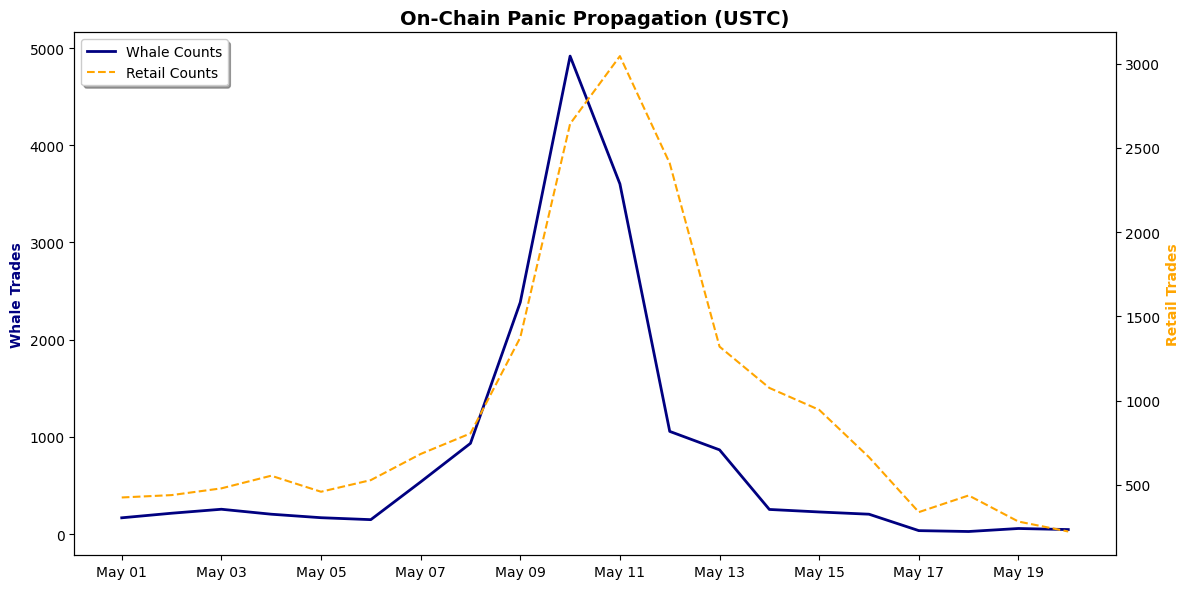

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the user's data to simulate/verify
ustc_data = whale_retail_summary.copy()
ustc_data = ustc_data[ustc_data['token'] == 'USTC'].copy()
ustc_data['date'] = pd.to_datetime(ustc_data['date'])
ustc_data = ustc_data[(ustc_data['date'] >= pd.Timestamp('2022-05-01')) & 
                     (ustc_data['date'] <= pd.Timestamp('2022-05-20'))].sort_values('date')

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting on ax1 (Left)
lns1 = ax1.plot(ustc_data['date'], ustc_data['whale_count'], color='navy', label='Whale Counts', linewidth=2)
ax1.set_ylabel('Whale Trades', color='navy', fontweight='bold')

# Plotting on ax2 (Right)
ax2 = ax1.twinx()
lns2 = ax2.plot(ustc_data['date'], ustc_data['retail_count'], color='orange', linestyle='--', label='Retail Counts')
ax2.set_ylabel('Retail Trades', color='orange', fontweight='bold')

# --- FIX: Combining legends ---
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True, shadow=True)

plt.title("On-Chain Panic Propagation (USTC)", fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.tight_layout()
plt.show()

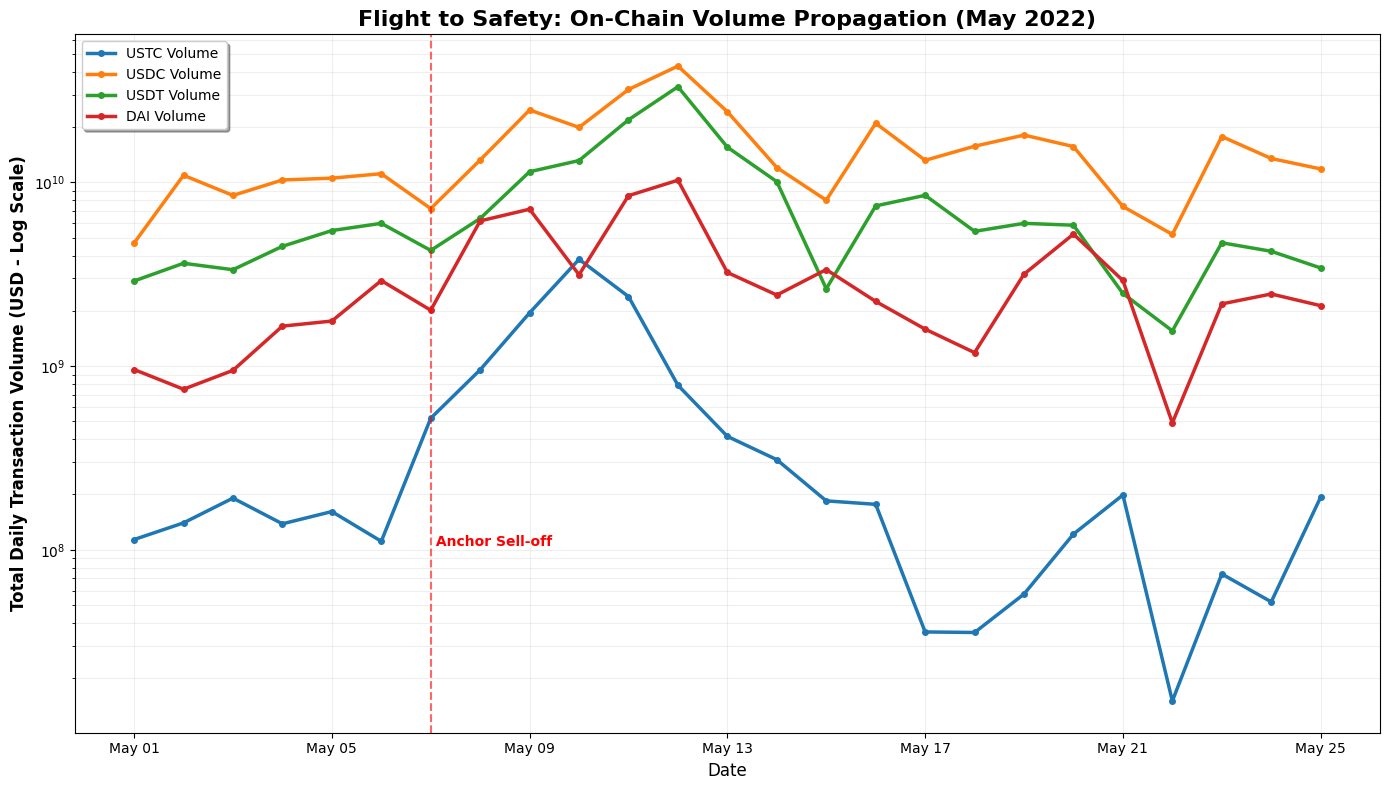

In [14]:
# 1. Load the summary data created from your 6GB file
whale_retail_summary['date'] = pd.to_datetime(whale_retail_summary['date'])

# 2. Define the tokens and the crisis window
# We include USTC (the source of panic) and the safe havens
tokens_of_interest = ['USTC', 'USDC', 'USDT', 'DAI']
start_date = '2022-05-01'
end_date = '2022-05-25'

# 3. Filter and Sort
plot_data = whale_retail_summary[
    (whale_retail_summary['token'].isin(tokens_of_interest)) & 
    (whale_retail_summary['date'] >= start_date) & 
    (whale_retail_summary['date'] <= end_date)
].sort_values(['date', 'token'])

# 4. Create the Plot
plt.figure(figsize=(14, 8))

for token in tokens_of_interest:
    token_subset = plot_data[plot_data['token'] == token]
    
    # We use 'total_volume' to show the massive movement of capital
    plt.plot(token_subset['date'], token_subset['total_volume'], 
             label=f'{token} Volume', linewidth=2.5, marker='o', markersize=4)

# 5. Formatting for "Academic Rigor"
plt.yscale('log') # CRITICAL: Allows comparison across different scales
plt.title("Flight to Safety: On-Chain Volume Propagation (May 2022)", fontsize=16, fontweight='bold')
plt.ylabel("Total Daily Transaction Volume (USD - Log Scale)", fontsize=12, fontweight='bold')
plt.xlabel("Date", fontsize=12)

# Add a vertical line for the "Trigger Event" (Anchor sell-off)
plt.axvline(pd.to_datetime('2022-05-07'), color='red', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2022-05-07'), plt.ylim()[0]*10, ' Anchor Sell-off', 
         color='red', fontweight='bold', rotation=0, va='bottom')

# Legend and Grid
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.savefig('../figures/stablecoin_flight_volume.png', dpi=300)
plt.show()